# Tracking *in situ* observsations through storm tracks

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/c3s-training-submodule-insitu-obs/main?labpath=insitu-obs-against-climatology.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/c3s-training-submodule-insitu-obs/blob/main/insitu-obs-against-climatology.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/c3s-training-submodule-insitu-obs/blob/main/insitu-obs-against-climatology.ipynb)

:::{note}
This notebook can be run on free online platforms, such as Binder, Kaggle and Colab, or they can be accessed from GitHub. The links to run this notebook in these environments are provided here, but please note they are not supported by ECMWF.
:::

*Provide an introduction and context for the notebook here.*


## Learning objectives 🎯


This notebook will teach you how to:
1. Access data from the Climate Data Store using `earthkit-data`
2. Calculate climatological averages using `earthkit-transforms`
3. Create publication quality figures comparing the data sources using `earthkit-plots`


## Prepare your environment


*Insert here any necessary instructions to set-up the environment of learners, any background information on data, projects, access to data catalogues, or preliminary steps necessary to run the notebooks. These may include instructions for installing packages, imports, etc.*

:::{important}
All required dependencies should be included in the `environment.yml` file.
:::

### Import libraries


In [1]:
# Import your libraries here
import earthkit.data as ekd
import earthkit.transforms as ekt
import earthkit.plots as ekp

import numpy as np
import pandas as pd

## Download data from CDS

### Select a storm of interest

For this example demonstration, we will look at the
[Great Storm of 1987](https://en.wikipedia.org/wiki/Great_storm_of_1987).
The storm occured on the night of the 15th/16th October, we will look at the
antecedent build up of meteorological conditions and compare the observations
with the long-term climatological behaviour.

The [Windstorm tracks and footprints over Europe](https://cds.climate.copernicus.eu/datasets/sis-european-wind-storm-reanalysis?tab=overview)
dataset on the CDS has a number of wind storms to explore.

In [2]:
# Period and region of interest
year = "1987"
month = "10"
day = "15"

In [3]:
storm_dataset = "sis-european-wind-storm-reanalysis"
storm_request = {
    "product": "windstorm_track",
    "variable": "all",
    "tracking_algorithm": ["hodges"],
    "event_aggregation": "single_event",
    "year": year,
    "month": month,
    "day": day
}
storm_ekds = ekd.from_source("cds", storm_dataset, storm_request)
storm_df = storm_ekds.to_pandas()
storm_df["time"] = pd.to_datetime(storm_df["time"])
# Create an xarray dataset for later
storm_ds = storm_df.to_xarray()
storm_ds = storm_ds.assign_coords(time=storm_ds["time"], longitude=storm_ds["longitude"], latitude=storm_ds["latitude"])
storm_df[:2]

,id,time,latitude,longitude,fg10,lsm,msl,algorithm
0,1014,1987-10-15 00:00:00,42.25,-23.25,12.154546,0.0,98603.690,hodges
1,1014,1987-10-15 06:00:00,42.50,-17.50,5.343058,0.0,97911.625,hodges


With our storm selected, we can define an area and date range based on the information in the storm track DataFrame. We add some padding to make sure we capture enough of the weather system

In [4]:
min_lat = np.floor(storm_df.latitude.min() - 2).item()
max_lat = np.ceil(storm_df.latitude.max() + 2).item()
min_lon = np.floor(storm_df.longitude.min() - 2).item()
max_lon = np.ceil(storm_df.longitude.max() + 2).item()
area = [max_lat, min_lon, min_lat, max_lon]

start_date = storm_df.time.min()-pd.Timedelta(days=3)
end_date = storm_df.time.max()+pd.Timedelta(days=1)
daterange = f"{start_date.strftime('%Y-%m-%d')}/{end_date.strftime('%Y-%m-%d')}"
daterange

'1987-10-12/1987-10-18'

### Download ERA5 Hourly data that correspondes to the storm

In [5]:
era5_hourly_dataset = "reanalysis-era5-single-levels"
variables = [
    "2m_temperature",
    "total_precipitation",
    "sea_surface_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "mean_sea_level_pressure",
]
era5_hourly_request = {
    "product_type": ["reanalysis"],
    "variable": variables,
    "date": daterange,
    "time": [f"{i:02d}:00" for i in range(24)],
    "area": area,
}

era5_hourly_ekds = ekd.from_source("cds", era5_hourly_dataset, era5_hourly_request)
era5_hourly_ds = era5_hourly_ekds.to_xarray(time_dim_mode="valid_time")
era5_hourly_ds

<xarray.Dataset> Size: 147MB
Dimensions:     (valid_time: 168, latitude: 129, longitude: 141)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1kB 1987-10-12 ... 1987-10-18T23:...
  * latitude    (latitude) float64 1kB 72.0 71.75 71.5 71.25 ... 40.5 40.25 40.0
  * longitude   (longitude) float64 1kB -26.0 -25.75 -25.5 ... 8.5 8.75 9.0
Data variables:
    10u         (valid_time, latitude, longitude) float64 24MB ...
    10v         (valid_time, latitude, longitude) float64 24MB ...
    2t          (valid_time, latitude, longitude) float64 24MB ...
    msl         (valid_time, latitude, longitude) float64 24MB ...
    sst         (valid_time, latitude, longitude) float64 24MB ...
    tp          (valid_time, latitude, longitude) float64 24MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

### Download the *in situ* data that correspondes to the storm

In [6]:
start_day = start_date.day
end_day = end_date.day
if start_date.month != end_date.month:
    raise ValueError("Start and end dates must be within the same month for this example.")
dataset = "insitu-observations-surface-marine"
request = {
    "version": "2_0_0",
    "variable": [
        "air_pressure_at_sea_level",
        "air_temperature",
        "dew_point_temperature",
        "water_temperature",
        "wind_from_direction",
        "wind_speed"
    ],
    "year": start_date.year,
    "month": start_date.month,
    "day": [i for i in range(start_day, end_day + 1)],
    "area": area,
}
insitu_ekds = ekd.from_source("cds", dataset, request)
insitu_df = insitu_ekds.to_pandas()
insitu_ds = insitu_ekds.to_xarray()
insitu_ds["observed_variable"] = insitu_ds.observed_variable.str.decode("UTF-8")
insitu_ds["report_timestamp"].data = pd.to_datetime(insitu_ds["report_timestamp"].data)
# Assign some of the data variables as coordinates for easier selection and plotting
for coord in ["latitude", "longitude", "report_timestamp", "observed_variable", "observation_height_above_station_surface"]:
    insitu_ds = insitu_ds.assign_coords({coord: insitu_ds[coord]})
unique_observed_variables = insitu_ds.observed_variable.to_index().unique()
_, index = np.unique(insitu_ds["station_name"], return_index=True)
unique_stations = insitu_ds.sel(index=index)

insitu_ds

<xarray.Dataset> Size: 8MB
Dimensions:                                   (index: 33575)
Coordinates:
    longitude                                 (index) float32 134kB ...
    latitude                                  (index) float32 134kB ...
    observation_height_above_station_surface  (index) float32 134kB ...
    observed_variable                         (index) <U25 3MB 'air_temperatu...
    report_timestamp                          (index) datetime64[ns] 269kB 19...
Dimensions without coordinates: index
Data variables: (12/15)
    observation_id                            (index) |S26 873kB ...
    report_id                                 (index) |S22 739kB ...
    data_policy_licence                       (index) int32 134kB ...
    observation_value                         (index) float64 269kB ...
    value_significance                        (index) int32 134kB ...
    units                                     (index) |S3 101kB ...
    ...                                        ...
    station_name                              (index) |S25 839kB b'TELLIER' ....
    platform_type                             (index) int32 134kB ...
    primary_station_id                        (index) |S9 302kB ...
    height_of_station_above_sea_level         (index) float32 134kB ...
    report_meaning_of_timestamp               (index) int32 134kB ...
    report_duration                           (index) int32 134kB ...
Attributes:
    featureType:               point
    contactemail:              https://support.ecmwf.int
    licence_list:              licence-to-use-copernicus-products
    responsible_organisation:  ECMWF

## Plot maps of the storm progression

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_22568/1007821275.py:3: DeprecationWarning: The 'size' argument is deprecated and will be removed in a future release. Use 'figsize' instead.
  figure = ekp.Figure(domain=[area[1], area[3], area[2], area[0]], size=(9, 7),  crs=ccrs.PlateCarree(), rows=3, columns=4)


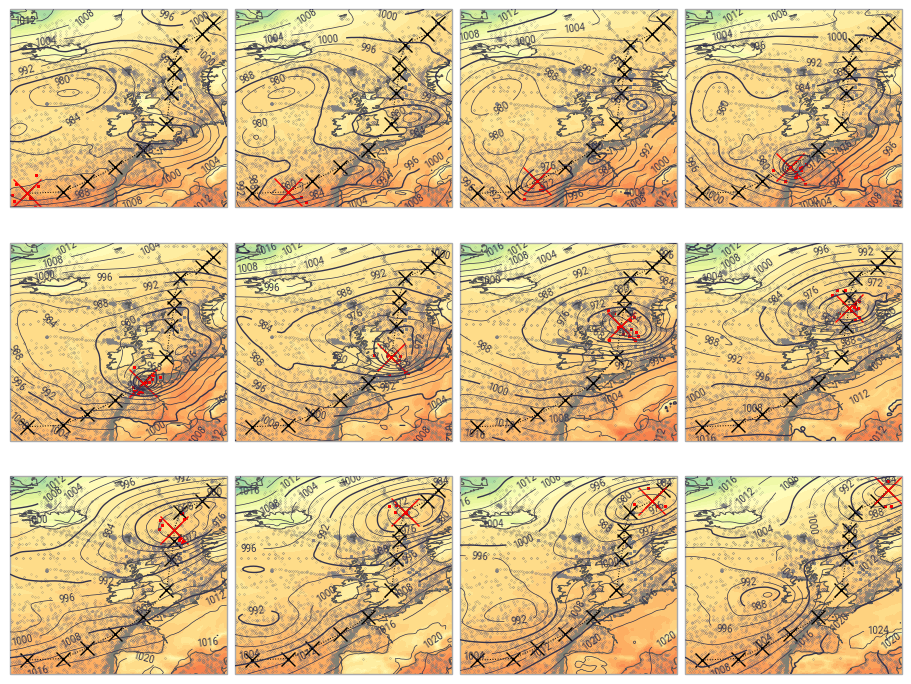

In [26]:
from cartopy import crs as ccrs

figure = ekp.Figure(domain=[area[1], area[3], area[2], area[0]], size=(9, 7),  crs=ccrs.PlateCarree(), rows=3, columns=4)

for i, istorm in enumerate(storm_ds.index):
    ds = era5_hourly_ds.sel(valid_time=istorm.time.data, method="nearest").squeeze()
    chart = figure.add_map()
    chart.quickplot(ds['2t'], units="celsius")
    chart.quickplot(ds['msl'], units="hPa")
    chart.coastlines()
    
    chart.ax.scatter(
        insitu_ds.longitude,
        insitu_ds.latitude,
        marker = ".", color='grey', s=0.01
    )
    chart.ax.plot(
        storm_ds["longitude"],
        storm_ds["latitude"],
        marker = "x", color='black', ls=':', lw=0.7, ms=10
    )

    storm_point = storm_ds.sel(
        time=istorm.time.data, method="nearest"
    )
    chart.ax.plot(
        istorm["longitude"],
        istorm["latitude"],
        marker = "x", color='red', ls=':', lw=1, ms=20
    )
    
    # plot stations within 5 degrees of the storm point
    nearby_stations = insitu_ds.where(
        (insitu_ds.longitude > storm_point["longitude"].item() - 3) & 
        (insitu_ds.longitude < storm_point["longitude"].item() + 3) &
        (insitu_ds.latitude > storm_point["latitude"].item() - 3) & 
        (insitu_ds.latitude < storm_point["latitude"].item() + 3) &
        (pd.to_datetime(insitu_ds.report_timestamp) > istorm.time.data - pd.Timedelta(hours=6)) &
        (pd.to_datetime(insitu_ds.report_timestamp) < istorm.time.data + pd.Timedelta(hours=6)),
        drop=True
    )
    chart.ax.scatter(
        nearby_stations.longitude,
        nearby_stations.latitude,
        marker = ".", color='red', s=5
    )

## Plot a time-series of the observations against the reanalysis for each point in our storm track

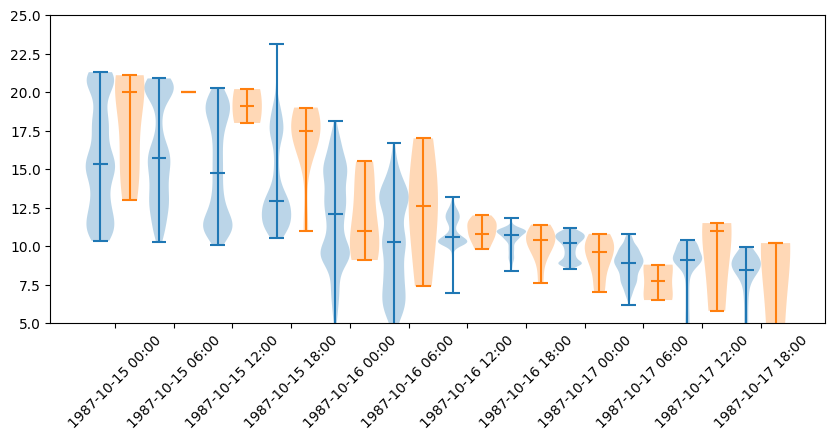

In [27]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

spatial_box_width = 3
temporal_window = pd.Timedelta(hours=1)

era5_data = [
    era5_hourly_ds.sel(
        longitude=slice(storm_ds.longitude[istorm].item() - spatial_box_width, storm_ds.longitude[istorm].item() + spatial_box_width),
        latitude=slice(storm_ds.latitude[istorm].item() + spatial_box_width, storm_ds.latitude[istorm].item() - spatial_box_width),
    ).sel(
        valid_time=slice(
            pd.to_datetime(storm_ds.time[istorm].item()) - temporal_window,
            pd.to_datetime(storm_ds.time[istorm].item()) + temporal_window
        )
    )["2t"].values.flatten() - 273.15
    for istorm in storm_ds.index
]
insitu_data = [
    insitu_ds.where(
        (insitu_ds.longitude > storm_ds.longitude[istorm].item() - spatial_box_width) &
        (insitu_ds.longitude < storm_ds.longitude[istorm].item() + spatial_box_width) &
        (insitu_ds.latitude < storm_ds.latitude[istorm].item() + spatial_box_width) &
        (insitu_ds.latitude > storm_ds.latitude[istorm].item() - spatial_box_width) &
        (insitu_ds.observed_variable == "air_temperature") &
        (insitu_ds.report_timestamp >= pd.to_datetime(storm_ds.time[istorm].item()) - temporal_window) &
        (insitu_ds.report_timestamp <= pd.to_datetime(storm_ds.time[istorm].item()) + temporal_window),
        drop=True
    )["observation_value"].values - 273.15
    for istorm in storm_ds.index
]

fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.violinplot(era5_data, positions=np.arange(1, len(storm_ds.time) + 1)-0.25, showmeans=False, showmedians=True)
ax1.violinplot(insitu_data, positions=np.arange(1, len(storm_ds.time) + 1)+0.25, showmeans=False, showmedians=True)
ax1.set_xticks(np.arange(1, len(storm_ds.time) + 1))
ax1.set_xticklabels(storm_ds.time.dt.strftime('%Y-%m-%d %H:%M').values, rotation=45)
ax1.set_ylim(5, 25)

plt.show()
    

## Take home messages 📌


*In this section, summarise key take home messages.*

- *Key message 1*
- *Key message 2*
- *Key message 3*
